# Band Ablation Analysis (Parietal, PLV+BE Combined)

目標：在 Parietal 腦區上，找出哪些頻帶 (delta/theta/alpha/beta/gamma) 是必要的、哪些可以移除。

三個分析：
1. **Leave-One-Band-Out (LOBO)** — 一次拿掉一個 band，看 acc 掉多少。
2. **Single-Band only** — 只用一個 band，看單獨表現。
3. **All 31 combinations** — 窮舉所有非空 band 子集。

Pipeline 與 `svm_plv_be_combined.ipynb` 一致：PLV/BE 各自 StandardScaler→PCA(0.95)→concat→StandardScaler→SVC(rbf,C=10,balanced)，LOSO。

In [45]:
import os
import json
from itertools import combinations

import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score

In [46]:
# ── 通道/腦區/頻帶定義 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7',
    'O1','Oz','O2',
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8',
    'FT10','FC6','FC2','F4','F8','Fp2'
]

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}

BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

TARGET_REGION = 'Parietal'
TARGET_CH_IDX = REGIONS[TARGET_REGION]

In [47]:
# ── 資料載入（與 svm_plv_be_combined 相同）──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_plv(filepath):
    with h5py.File(filepath, 'r') as f:
        rm = f['result_mats']
        bands_data = [np.array(rm[b]) for b in BAND_NAMES]
    return np.array(bands_data)  # (5, 200, 32, 32)

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data  # (32, 39, 5)

def load_plv_group(maps, subs):
    out = [[], [], []]
    for sub in subs:
        for i in range(3):
            out[i].append(load_plv(maps[i][sub]))
    return [np.array(x) for x in out]

def load_be_group(maps, subs):
    out = [[], [], []]
    for sub in subs:
        for i in range(3):
            out[i].append(load_band_energy(maps[i][sub]))
    return [np.array(x) for x in out]

BASE_PLV = {
    'amateur': r'D:\Tseng\圍棋\amateur\PLV_Results_2026',
    'master':  r'D:\Tseng\圍棋\master\PLV_Results_2026',
    'prof':    r'D:\Tseng\圍棋\prof\PLV_Results_2026',
}
BASE_BE = {
    'amateur': r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026',
    'master':  r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026',
    'prof':    r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026',
}

plv_maps, be_maps, complete = {}, {}, {}
for group in CLASS_NAMES:
    pmaps = [scan_folder(os.path.join(BASE_PLV[group], s)) for s in ['ss01','ss02','ss03']]
    bmaps = [scan_folder(os.path.join(BASE_BE[group],  s)) for s in ['ss01','ss02','ss03']]
    plv_maps[group] = pmaps
    be_maps[group]  = bmaps
    complete[group] = sorted(set(pmaps[0]) & set(pmaps[1]) & set(pmaps[2]))
    print(f'[{group}] 完整 subject：{len(complete[group])}')

print('\n載入 PLV...')
plv_groups = {g: load_plv_group(plv_maps[g], complete[g]) for g in CLASS_NAMES}
print('載入 BE...')
be_groups  = {g: load_be_group(be_maps[g],  complete[g]) for g in CLASS_NAMES}

X_plv = np.vstack([x for g in CLASS_NAMES for x in plv_groups[g]])  # (168,5,200,32,32)
X_be  = np.vstack([x for g in CLASS_NAMES for x in be_groups[g]])   # (168,32,39,5)

n_a, n_m, n_p = (len(complete[g]) for g in CLASS_NAMES)
y_all = np.concatenate([np.zeros(n_a*3), np.ones(n_m*3), np.full(n_p*3, 2)]).astype(int)
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'],  3),
    np.repeat(complete['prof'],    3),
])
subject_labels = {s: g_idx for g_idx, g in enumerate(CLASS_NAMES) for s in complete[g]}

print(f'\nX_plv: {X_plv.shape}  X_be: {X_be.shape}  y: {y_all.shape}')

[amateur] 完整 subject：28
[master] 完整 subject：20
[prof] 完整 subject：8

載入 PLV...
載入 BE...

X_plv: (168, 5, 200, 32, 32)  X_be: (168, 32, 39, 5)  y: (168,)


In [48]:
# ── 特徵提取（支援 band 子集）+ LOSO pipeline ──

def extract_plv_features(X, ch_idx, band_idx):
    """X: (N,5,200,32,32) -> mean over time -> 取選定 ch+band -> upper triangle 攤平"""
    X_mean = X.mean(axis=2)  # (N,5,32,32)
    X_mean = X_mean[:, band_idx][:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
    n_ch = len(ch_idx)
    tri = np.triu_indices(n_ch, k=1)
    feats = [X_mean[:, b, tri[0], tri[1]] for b in range(len(band_idx))]
    return np.hstack(feats)

def extract_be_features(X_be, ch_idx, band_idx):
    """X_be: (N,32,39,5) -> log -> 去頭尾時間 -> 平均時間 -> 取選定 ch+band"""
    X = np.log(X_be + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)  # (N,32,5)
    X = X[:, ch_idx, :][:, :, band_idx]
    return X.reshape(len(X), -1)

def run_loso(feat_plv, feat_be, y_all, subject_split, subject_ids, pca_variance=0.95):
    all_preds, all_true = [], []
    pca_plv_dims, pca_be_dims = [], []
    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask
        y_tr = y_all[train_mask]
        y_te = y_all[test_mask]

        # PLV branch
        plv_tr, plv_te = feat_plv[train_mask], feat_plv[test_mask]
        sc1 = StandardScaler().fit(plv_tr)
        plv_tr, plv_te = sc1.transform(plv_tr), sc1.transform(plv_te)
        pca1 = PCA(n_components=pca_variance).fit(plv_tr)
        plv_tr, plv_te = pca1.transform(plv_tr), pca1.transform(plv_te)
        pca_plv_dims.append(pca1.n_components_)

        # BE branch
        be_tr, be_te = feat_be[train_mask], feat_be[test_mask]
        sc2 = StandardScaler().fit(be_tr)
        be_tr, be_te = sc2.transform(be_tr), sc2.transform(be_te)
        pca2 = PCA(n_components=pca_variance).fit(be_tr)
        be_tr, be_te = pca2.transform(be_tr), pca2.transform(be_te)
        pca_be_dims.append(pca2.n_components_)

        # concat + scale + SVC
        X_tr = np.hstack([plv_tr, be_tr])
        X_te = np.hstack([plv_te, be_te])
        sc3 = StandardScaler().fit(X_tr)
        X_tr, X_te = sc3.transform(X_tr), sc3.transform(X_te)

        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    return acc, f1, int(np.median(pca_plv_dims)), int(np.median(pca_be_dims))

def evaluate_band_subset(band_idx, ch_idx=TARGET_CH_IDX):
    feat_plv = extract_plv_features(X_plv, ch_idx, band_idx)
    feat_be  = extract_be_features(X_be,   ch_idx, band_idx)
    acc, f1, dp, db = run_loso(feat_plv, feat_be, y_all, subject_split, subject_ids)
    return {
        'acc': acc, 'f1': f1,
        'plv_dims': feat_plv.shape[1], 'be_dims': feat_be.shape[1],
        'pca_plv': dp, 'pca_be': db,
    }

# Baseline：全部 5 個 band
print('Baseline (all 5 bands)...')
baseline = evaluate_band_subset(list(range(5)))
print(f'  Acc={baseline["acc"]:.3f}  F1={baseline["f1"]:.3f}  '
      f'PLV={baseline["plv_dims"]}(→{baseline["pca_plv"]}) + BE={baseline["be_dims"]}(→{baseline["pca_be"]})')

Baseline (all 5 bands)...
  Acc=0.839  F1=0.838  PLV=180(→21) + BE=45(→7)


In [49]:
# ── 分析 1：Leave-One-Band-Out (LOBO) ──

lobo_results = {}
print('=' * 78)
print(f'LOBO @ {TARGET_REGION} — baseline Acc={baseline["acc"]:.3f}  F1={baseline["f1"]:.3f}')
print('=' * 78)
print(f'{"Removed":<10s} {"Kept":<35s} {"Acc":>7s} {"ΔAcc":>7s} {"F1":>7s} {"ΔF1":>7s}')
print('-' * 78)

for drop_i, drop_name in enumerate(BAND_NAMES):
    keep_idx = [i for i in range(5) if i != drop_i]
    keep_names = [BAND_NAMES[i] for i in keep_idx]
    res = evaluate_band_subset(keep_idx)
    res['dropped'] = drop_name
    res['kept'] = keep_names
    lobo_results[drop_name] = res
    d_acc = res['acc'] - baseline['acc']
    d_f1  = res['f1']  - baseline['f1']
    print(f'{drop_name:<10s} {",".join(keep_names):<35s} '
          f'{res["acc"]:7.3f} {d_acc:+7.3f} {res["f1"]:7.3f} {d_f1:+7.3f}')
print('=' * 78)
print('解讀：ΔAcc 越負代表移除該 band 後掉得越多（=該 band 越重要）；')
print('      ΔAcc≥0 代表該 band 可以拿掉甚至有幫助。')

LOBO @ Parietal — baseline Acc=0.839  F1=0.838
Removed    Kept                                    Acc    ΔAcc      F1     ΔF1
------------------------------------------------------------------------------
delta      theta,alpha,beta,gamma                0.810  -0.030   0.803  -0.035
theta      delta,alpha,beta,gamma                0.851  +0.012   0.851  +0.013
alpha      delta,theta,beta,gamma                0.833  -0.006   0.842  +0.004
beta       delta,theta,alpha,gamma               0.804  -0.036   0.805  -0.033
gamma      delta,theta,alpha,beta                0.863  +0.024   0.852  +0.014
解讀：ΔAcc 越負代表移除該 band 後掉得越多（=該 band 越重要）；
      ΔAcc≥0 代表該 band 可以拿掉甚至有幫助。


In [50]:
# ── 分析 2：Single-Band only ──

single_results = {}
print('=' * 70)
print(f'Single-Band @ {TARGET_REGION}')
print('=' * 70)
print(f'{"Band":<10s} {"PLV dims":>10s} {"BE dims":>9s} {"Acc":>7s} {"F1":>7s}')
print('-' * 70)

for i, name in enumerate(BAND_NAMES):
    res = evaluate_band_subset([i])
    single_results[name] = res
    print(f'{name:<10s} {res["plv_dims"]:>10d} {res["be_dims"]:>9d} '
          f'{res["acc"]:7.3f} {res["f1"]:7.3f}')
print('=' * 70)

Single-Band @ Parietal
Band         PLV dims   BE dims     Acc      F1
----------------------------------------------------------------------
delta              36         9   0.756   0.738
theta              36         9   0.738   0.731
alpha              36         9   0.768   0.774
beta               36         9   0.780   0.760
gamma              36         9   0.679   0.687


In [51]:
# ── 分析 3：所有 31 種非空 band 子集 ──

all_subsets = []
for k in range(1, 6):
    for combo in combinations(range(5), k):
        all_subsets.append(list(combo))

print(f'總共 {len(all_subsets)} 種子集，跑 LOSO 中...')
subset_results = []
for idx, subset in enumerate(all_subsets):
    names = [BAND_NAMES[i] for i in subset]
    res = evaluate_band_subset(subset)
    res['subset'] = subset
    res['names'] = names
    res['k'] = len(subset)
    subset_results.append(res)
    print(f'  [{idx+1:2d}/31] k={len(subset)}  {",".join(names):<35s}  '
          f'Acc={res["acc"]:.3f}  F1={res["f1"]:.3f}')

# 排序：先按 acc 降序，再按 k 升序（同 acc 偏好較少 band）
subset_results_sorted = sorted(subset_results, key=lambda r: (-r['acc'], r['k']))

print('\n' + '=' * 78)
print('Top 10 子集（依 Acc 排序，同 Acc 偏好較少 band）')
print('=' * 78)
print(f'{"Rank":<5s} {"k":<3s} {"Bands":<35s} {"Acc":>7s} {"F1":>7s} {"ΔAcc":>8s}')
print('-' * 78)
for rank, r in enumerate(subset_results_sorted[:10], 1):
    d_acc = r['acc'] - baseline['acc']
    print(f'{rank:<5d} {r["k"]:<3d} {",".join(r["names"]):<35s} '
          f'{r["acc"]:7.3f} {r["f1"]:7.3f} {d_acc:+8.3f}')
print('=' * 78)

總共 31 種子集，跑 LOSO 中...
  [ 1/31] k=1  delta                                Acc=0.756  F1=0.738
  [ 2/31] k=1  theta                                Acc=0.738  F1=0.731
  [ 3/31] k=1  alpha                                Acc=0.768  F1=0.774
  [ 4/31] k=1  beta                                 Acc=0.780  F1=0.760
  [ 5/31] k=1  gamma                                Acc=0.679  F1=0.687
  [ 6/31] k=2  delta,theta                          Acc=0.750  F1=0.755
  [ 7/31] k=2  delta,alpha                          Acc=0.810  F1=0.816
  [ 8/31] k=2  delta,beta                           Acc=0.839  F1=0.833
  [ 9/31] k=2  delta,gamma                          Acc=0.756  F1=0.763
  [10/31] k=2  theta,alpha                          Acc=0.756  F1=0.756
  [11/31] k=2  theta,beta                           Acc=0.798  F1=0.796
  [12/31] k=2  theta,gamma                          Acc=0.768  F1=0.781
  [13/31] k=2  alpha,beta                           Acc=0.833  F1=0.837
  [14/31] k=2  alpha,gamma                

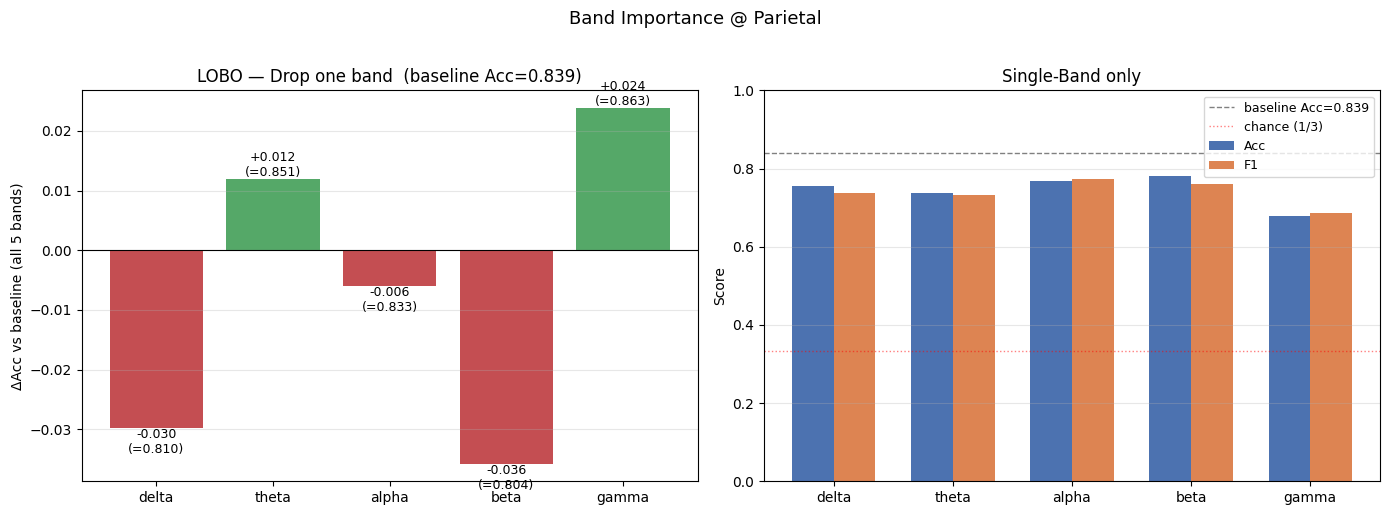

In [52]:
# ── 視覺化 1：LOBO + Single-Band Bar Chart ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BAND_NAMES))

# LOBO
ax = axes[0]
lobo_acc = [lobo_results[b]['acc'] for b in BAND_NAMES]
delta_acc = [a - baseline['acc'] for a in lobo_acc]
colors = ['#C44E52' if d < 0 else '#55A868' for d in delta_acc]
bars = ax.bar(x, delta_acc, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('ΔAcc vs baseline (all 5 bands)')
ax.set_title(f'LOBO — Drop one band  (baseline Acc={baseline["acc"]:.3f})')
for b, d, a in zip(bars, delta_acc, lobo_acc):
    ax.text(b.get_x() + b.get_width()/2, d, f'{d:+.3f}\n(={a:.3f})',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Single-Band
ax = axes[1]
single_acc = [single_results[b]['acc'] for b in BAND_NAMES]
single_f1  = [single_results[b]['f1']  for b in BAND_NAMES]
w = 0.35
ax.bar(x - w/2, single_acc, w, label='Acc',  color='#4C72B0')
ax.bar(x + w/2, single_f1,  w, label='F1',   color='#DD8452')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1, label=f'baseline Acc={baseline["acc"]:.3f}')
ax.axhline(1/3, color='red', ls=':', lw=1, alpha=0.5, label='chance (1/3)')
ax.set_xticks(x)
ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('Score')
ax.set_title('Single-Band only')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Band Importance @ {TARGET_REGION}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_lobo_single.png',
            dpi=150, bbox_inches='tight')
plt.show()

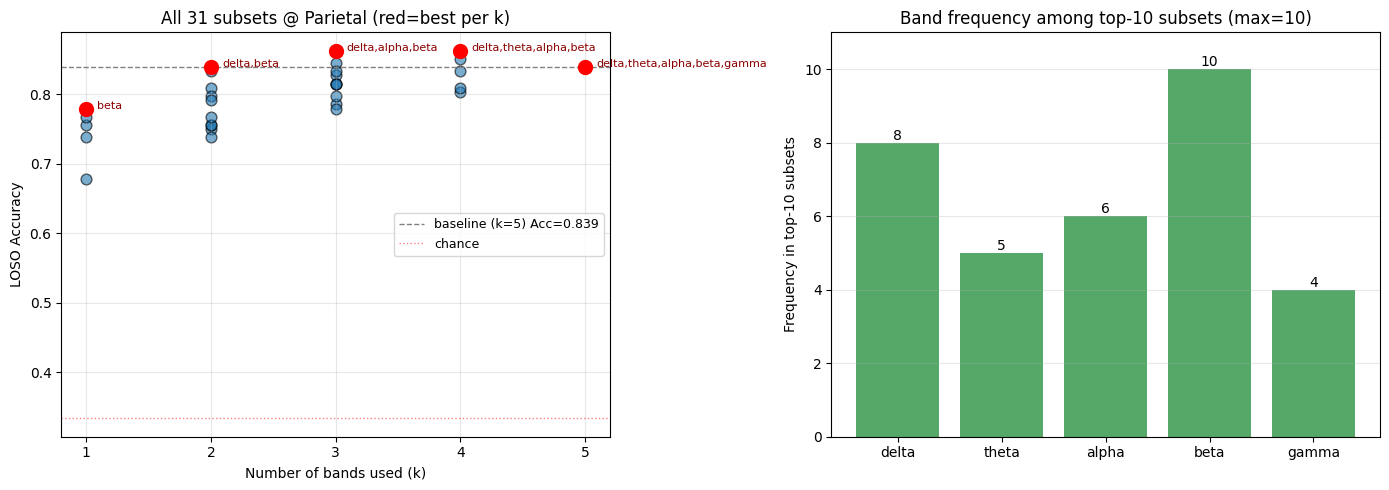

In [53]:
# ── 視覺化 2：所有 31 子集散點圖（k vs Acc）+ band 出現頻率 ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散點：k vs Acc
ax = axes[0]
ks   = [r['k']   for r in subset_results]
accs = [r['acc'] for r in subset_results]
ax.scatter(ks, accs, alpha=0.6, s=60, edgecolor='black')
# 標出每個 k 的最佳 Acc
best_per_k = {}
for r in subset_results:
    if r['k'] not in best_per_k or r['acc'] > best_per_k[r['k']]['acc']:
        best_per_k[r['k']] = r
for k, r in best_per_k.items():
    ax.scatter([k], [r['acc']], color='red', s=100, zorder=5)
    ax.annotate(','.join(r['names']), (k, r['acc']),
                xytext=(8, 0), textcoords='offset points', fontsize=8, color='darkred')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1, label=f'baseline (k=5) Acc={baseline["acc"]:.3f}')
ax.axhline(1/3, color='red', ls=':', lw=1, alpha=0.5, label='chance')
ax.set_xlabel('Number of bands used (k)')
ax.set_ylabel('LOSO Accuracy')
ax.set_title(f'All 31 subsets @ {TARGET_REGION} (red=best per k)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Band 出現頻率：在 top-K 子集中各 band 出現幾次
ax = axes[1]
TOP_K = 10
top_subsets = subset_results_sorted[:TOP_K]
band_count = {b: 0 for b in BAND_NAMES}
for r in top_subsets:
    for n in r['names']:
        band_count[n] += 1
counts = [band_count[b] for b in BAND_NAMES]
ax.bar(BAND_NAMES, counts, color='#55A868')
for i, c in enumerate(counts):
    ax.text(i, c, str(c), ha='center', va='bottom', fontsize=10)
ax.set_ylabel(f'Frequency in top-{TOP_K} subsets')
ax.set_title(f'Band frequency among top-{TOP_K} subsets (max={TOP_K})')
ax.set_ylim(0, TOP_K + 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_subsets.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# ── 結果存檔（JSON）──

out = {
    'region': TARGET_REGION,
    'baseline': baseline,
    'lobo': lobo_results,
    'single': single_results,
    'all_subsets': [
        {'k': r['k'], 'names': r['names'], 'acc': r['acc'], 'f1': r['f1'],
         'pca_plv': r['pca_plv'], 'pca_be': r['pca_be']}
        for r in subset_results
    ],
}
out_path = r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_ablation_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(out, f, ensure_ascii=False, indent=2, default=lambda o: float(o) if hasattr(o,'item') else o)
print(f'Saved: {out_path}')

Saved: D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_ablation_results.json


Raw features: PLV=108 + BE=27 = 135 dims
PCA dims: PLV 18 + BE 5 = 23
In-sample Acc (SHAP background model): 1.000
  注意: in-sample acc 不是評估指標, LOSO Acc=0.863 才是真實表現
Running SHAP KernelExplainer (預估 5~10 分鐘)...


PermutationExplainer explainer: 169it [00:30,  3.70it/s]                         


SHAP 完成, 耗時 31s (0.5 分鐘)
Saved: shap_values_best_config.npz


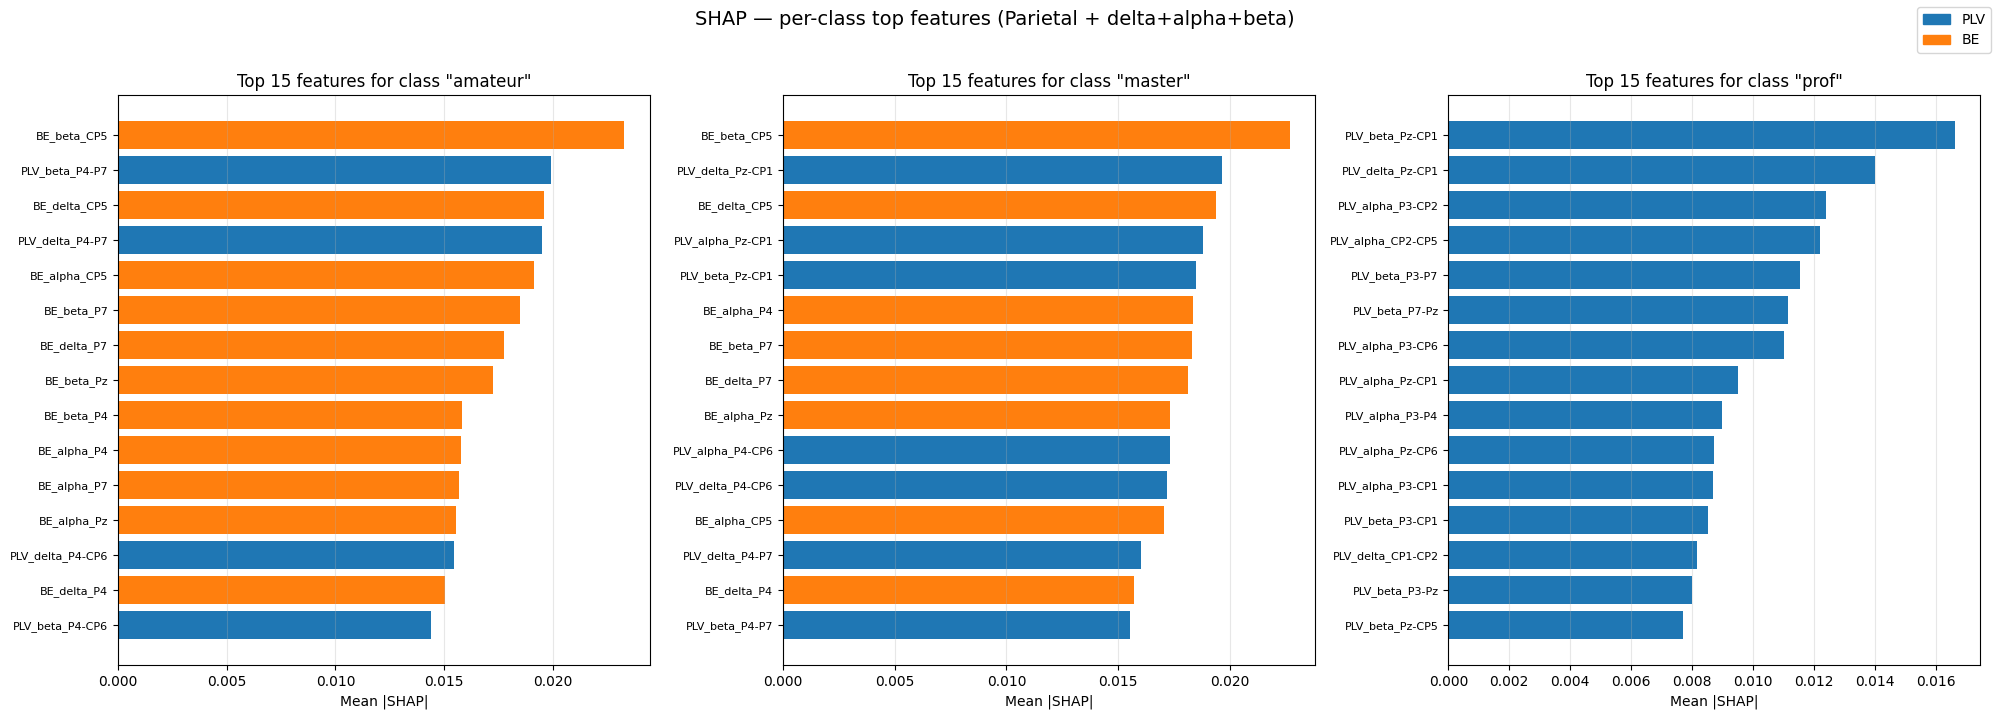

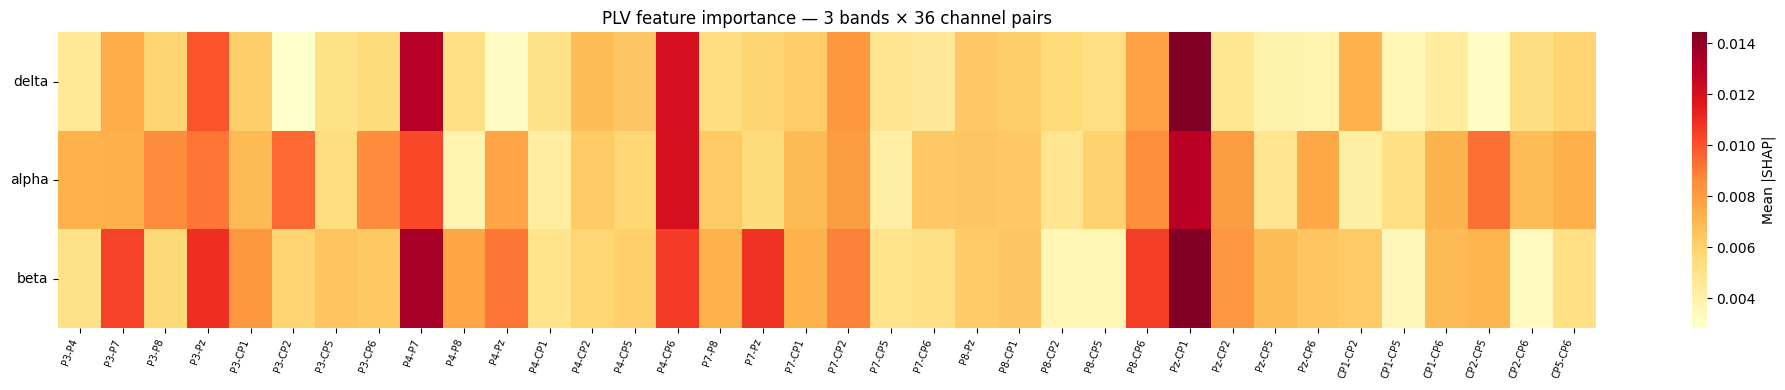

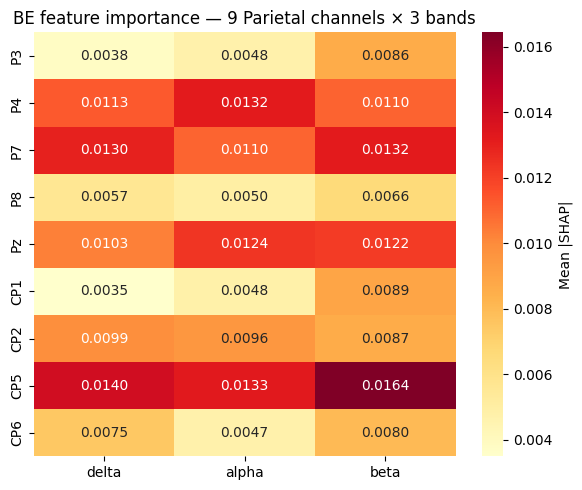

SHAP 全域 importance 排名 (Top 10)
   1. BE_beta_CP5                          |SHAP|=0.0164
   2. PLV_delta_Pz-CP1                     |SHAP|=0.0144
   3. PLV_beta_Pz-CP1                      |SHAP|=0.0143
   4. BE_delta_CP5                         |SHAP|=0.0140
   5. PLV_beta_P4-P7                       |SHAP|=0.0135
   6. BE_alpha_CP5                         |SHAP|=0.0133
   7. BE_alpha_P4                          |SHAP|=0.0132
   8. BE_beta_P7                           |SHAP|=0.0132
   9. PLV_delta_P4-P7                      |SHAP|=0.0131
  10. PLV_alpha_Pz-CP1                     |SHAP|=0.0130
讀圖建議:
  - Top 15 per class: 對於分某一類, SVM 主要看哪幾個特徵
  - PLV heatmap: 哪一條 channel pair / 哪個 band 對 SVM 最重要
  - BE heatmap: 哪一個 channel 在哪個 band 上對 SVM 最重要
  - 對應 EEG 文獻: alpha/beta 在 parietal 區的同步通常與 attention/working memory 有關


In [55]:
# ── SHAP Analysis on Best Config: Parietal + delta+alpha+beta (PLV+BE) ──
# 解釋 SVM 是用哪些通道-頻帶特徵把 168 sessions 分成 amateur/master/prof
import shap, time
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ─── 1. 抽特徵 (跟 best config 完全一致) ───
ch_idx = REGIONS['Parietal']
band_idx = [0, 2, 3]   # delta, alpha, beta (BAND_NAMES = delta,theta,alpha,beta,gamma)
feat_plv = extract_plv_features(X_plv, ch_idx, band_idx)
feat_be  = extract_be_features(X_be,  ch_idx, band_idx)
X_raw = np.hstack([feat_plv, feat_be])
y_int = y_all.astype(int)
print(f'Raw features: PLV={feat_plv.shape[1]} + BE={feat_be.shape[1]} = {X_raw.shape[1]} dims')

# ─── 2. Build pipeline (fit on 全 168 - 純為了視覺化, 非評估) ───
sc_plv = StandardScaler().fit(feat_plv); plv_s = sc_plv.transform(feat_plv)
pca_plv = PCA(n_components=0.95).fit(plv_s); plv_pca = pca_plv.transform(plv_s)
sc_be = StandardScaler().fit(feat_be); be_s = sc_be.transform(feat_be)
pca_be = PCA(n_components=0.95).fit(be_s); be_pca = pca_be.transform(be_s)
X_concat = np.hstack([plv_pca, be_pca])
sc_final = StandardScaler().fit(X_concat); X_final = sc_final.transform(X_concat)
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
          random_state=42, probability=True).fit(X_final, y_int)
print(f'PCA dims: PLV {pca_plv.n_components_} + BE {pca_be.n_components_} = {X_final.shape[1]}')
print(f'In-sample Acc (SHAP background model): {(svm.predict(X_final) == y_int).mean():.3f}')
print('  注意: in-sample acc 不是評估指標, LOSO Acc=0.863 才是真實表現')

# ─── 3. Wrapper: raw input -> SVM probabilities ───
def predict_fn(X_raw_in):
    plv_in = X_raw_in[:, :feat_plv.shape[1]]
    be_in  = X_raw_in[:, feat_plv.shape[1]:]
    p = pca_plv.transform(sc_plv.transform(plv_in))
    b = pca_be.transform(sc_be.transform(be_in))
    return svm.predict_proba(sc_final.transform(np.hstack([p, b])))

# ─── 4. Feature names (要把 SHAP index 翻譯回有意義的物理含意) ───
PARI_NAMES = [CH_NAMES[i] for i in ch_idx]   # ['Pz','P4','P3','P8','CP1','CP5','CP6','TP9','TP10']
PAIRS = [(PARI_NAMES[i], PARI_NAMES[j])
         for i in range(len(ch_idx)) for j in range(i+1, len(ch_idx))]   # 36 pairs
SEL_BANDS = [BAND_NAMES[b] for b in band_idx]  # ['delta','alpha','beta']

feature_names = []
for band in SEL_BANDS:
    for c1, c2 in PAIRS:
        feature_names.append(f'PLV_{band}_{c1}-{c2}')
for ch in PARI_NAMES:
    for band in SEL_BANDS:
        feature_names.append(f'BE_{band}_{ch}')
assert len(feature_names) == X_raw.shape[1]

# ─── 5. SHAP KernelExplainer ───
print('Running SHAP KernelExplainer (預估 5~10 分鐘)...')
t0 = time.time()
background = shap.sample(X_raw, 30, random_state=42)
explainer = shap.PermutationExplainer(predict_fn, background)
explanation = explainer(X_raw, max_evals=500)
shap_values = explanation.values   # shape (168, 135, 3) for 3-class output
elapsed = time.time() - t0
print(f'SHAP 完成, 耗時 {elapsed:.0f}s ({elapsed/60:.1f} 分鐘)')

# PermutationExplainer 回傳 ndarray shape (N, F, 3); 拆成每類
sv_per_class = [shap_values[..., c] for c in range(3)]

# 存檔以免重跑
np.savez(r'D:\Tseng\game_eeg\SVM_PLV_BE\shap_values_best_config.npz',
         shap_amateur=sv_per_class[0], shap_master=sv_per_class[1], shap_prof=sv_per_class[2],
         X_raw=X_raw, feature_names=np.array(feature_names))
print('Saved: shap_values_best_config.npz')

# ─── 6. 視覺化 1: 每類前 15 名重要特徵 ───
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for c, (ax, cname) in enumerate(zip(axes, CLASS_NAMES)):
    importance = np.abs(sv_per_class[c]).mean(axis=0)
    top15 = np.argsort(importance)[-15:][::-1]
    colors = ['#1f77b4' if 'PLV' in feature_names[i] else '#ff7f0e' for i in top15]
    ax.barh(range(15), importance[top15][::-1], color=colors[::-1])
    ax.set_yticks(range(15))
    ax.set_yticklabels([feature_names[i] for i in top15][::-1], fontsize=8)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'Top 15 features for class "{cname}"')
    ax.grid(axis='x', alpha=0.3)
fig.legend([plt.matplotlib.patches.Patch(color='#1f77b4'),
            plt.matplotlib.patches.Patch(color='#ff7f0e')],
           ['PLV', 'BE'], loc='upper right', fontsize=10)
plt.suptitle('SHAP — per-class top features (Parietal + delta+alpha+beta)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\shap_per_class_top15.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 7. 視覺化 2: PLV importance heatmap (3 bands × 36 pairs) ───
mean_abs_global = np.mean([np.abs(sv).mean(axis=0) for sv in sv_per_class], axis=0)
plv_imp = mean_abs_global[:feat_plv.shape[1]].reshape(len(SEL_BANDS), -1)  # (3, 36)
fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(plv_imp, ax=ax, cmap='YlOrRd',
            yticklabels=SEL_BANDS,
            xticklabels=[f'{p[0]}-{p[1]}' for p in PAIRS],
            cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title('PLV feature importance — 3 bands × 36 channel pairs')
plt.xticks(rotation=70, ha='right', fontsize=7); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\shap_plv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 8. 視覺化 3: BE importance heatmap (9 channels × 3 bands) ───
be_imp = mean_abs_global[feat_plv.shape[1]:].reshape(len(ch_idx), len(SEL_BANDS))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(be_imp, ax=ax, cmap='YlOrRd', annot=True, fmt='.4f',
            yticklabels=PARI_NAMES, xticklabels=SEL_BANDS,
            cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title('BE feature importance — 9 Parietal channels × 3 bands')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\shap_be_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 9. 總結報告 ───
print('' + '=' * 70)
print('SHAP 全域 importance 排名 (Top 10)')
print('=' * 70)
top10 = np.argsort(mean_abs_global)[-10:][::-1]
for rank, idx in enumerate(top10, 1):
    print(f'  {rank:2d}. {feature_names[idx]:<35s}  |SHAP|={mean_abs_global[idx]:.4f}')

print('讀圖建議:')
print('  - Top 15 per class: 對於分某一類, SVM 主要看哪幾個特徵')
print('  - PLV heatmap: 哪一條 channel pair / 哪個 band 對 SVM 最重要')
print('  - BE heatmap: 哪一個 channel 在哪個 band 上對 SVM 最重要')
print('  - 對應 EEG 文獻: alpha/beta 在 parietal 區的同步通常與 attention/working memory 有關')

PLV=108d + BE=27d = 135 raw dims
LOSO Acc=0.863  F1=0.858
Vote Acc=0.946  F1=0.944
PCA dims: PLV 18 + BE 5 = 23


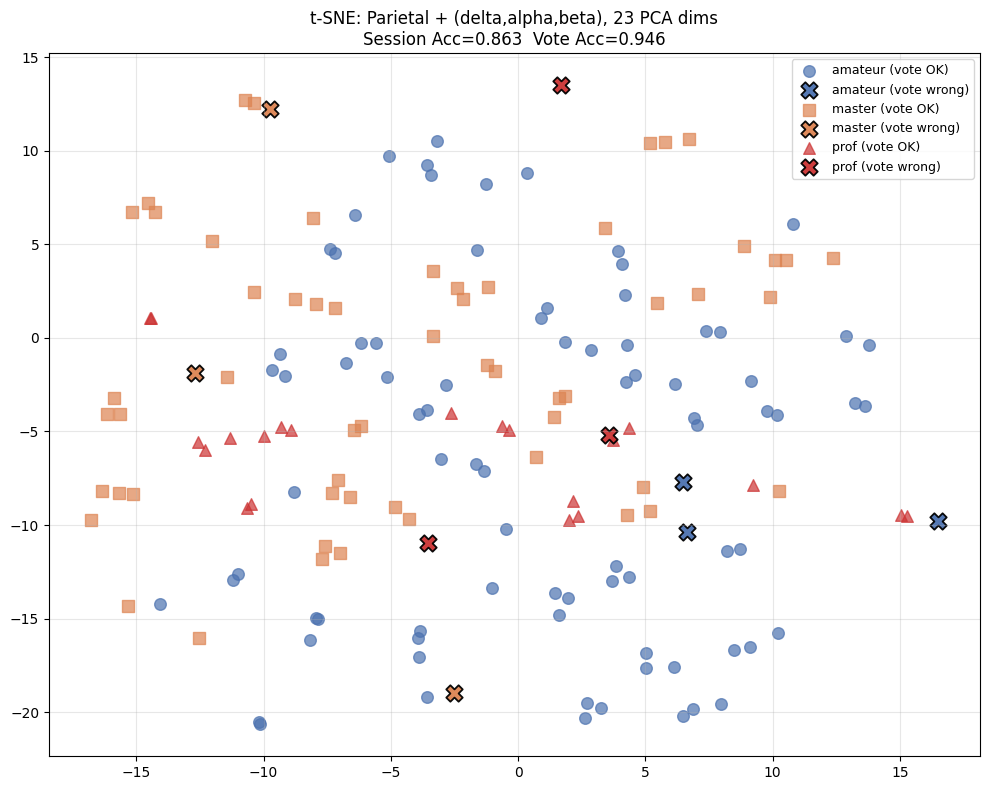

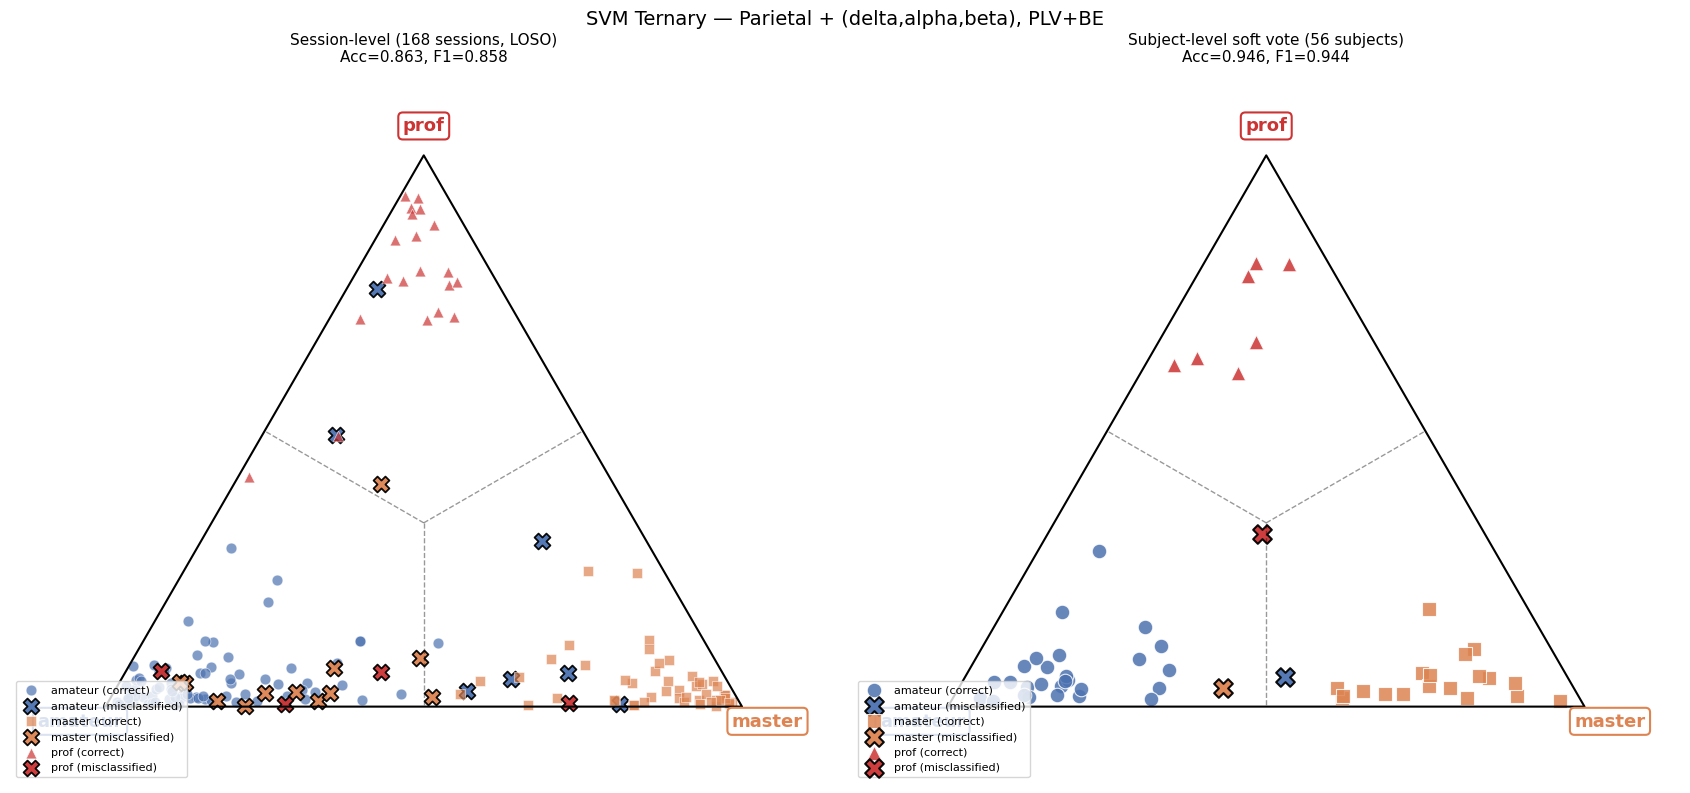

In [56]:
# ── 視覺化 best config: Parietal + delta+alpha+beta ──
# t-SNE (整體特徵分布) + Ternary plot (SVM 機率輸出)
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score

# ─── 1. 抽特徵 (跟 best config 完全一致) ───
ch_idx = REGIONS['Parietal']
band_idx = [0, 2, 3]   # delta, alpha, beta
feat_plv = extract_plv_features(X_plv, ch_idx, band_idx)
feat_be  = extract_be_features(X_be,  ch_idx, band_idx)
y_int = y_all.astype(int)
print(f'PLV={feat_plv.shape[1]}d + BE={feat_be.shape[1]}d = {feat_plv.shape[1]+feat_be.shape[1]} raw dims')

# ─── 2. LOSO 跑出每個 sample 的 predict_proba (Ternary 用) ───
all_proba = np.zeros((168, 3))
all_pred  = np.zeros(168, dtype=int)

for test_subject in subject_ids:
    m = subject_split == test_subject
    y_tr = y_all[~m].astype(int); y_te = y_all[m].astype(int)
    sc1 = StandardScaler().fit(feat_plv[~m])
    plv_tr = sc1.transform(feat_plv[~m]); plv_te = sc1.transform(feat_plv[m])
    pca1 = PCA(n_components=0.95).fit(plv_tr)
    plv_tr = pca1.transform(plv_tr); plv_te = pca1.transform(plv_te)
    sc2 = StandardScaler().fit(feat_be[~m])
    be_tr = sc2.transform(feat_be[~m]); be_te = sc2.transform(feat_be[m])
    pca2 = PCA(n_components=0.95).fit(be_tr)
    be_tr = pca2.transform(be_tr); be_te = pca2.transform(be_te)
    X_tr = np.hstack([plv_tr, be_tr]); X_te = np.hstack([plv_te, be_te])
    sc3 = StandardScaler().fit(X_tr)
    X_tr = sc3.transform(X_tr); X_te = sc3.transform(X_te)
    clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
              random_state=42, probability=True)
    clf.fit(X_tr, y_tr)
    test_idx = np.where(m)[0]
    all_proba[test_idx] = clf.predict_proba(X_te)
    all_pred[test_idx]  = clf.predict(X_te)

acc_session = (all_pred == y_int).mean()
f1_session  = f1_score(y_int, all_pred, average='macro', zero_division=0)
print(f'LOSO Acc={acc_session:.3f}  F1={f1_session:.3f}')

# Subject-level soft vote
sub_proba = np.array([all_proba[i*3:i*3+3].mean(axis=0) for i in range(len(subject_ids))])
sub_true  = np.array([subject_labels[s] for s in subject_ids])
sub_pred  = np.argmax(sub_proba, axis=1)
acc_vote = (sub_pred == sub_true).mean()
f1_vote  = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
print(f'Vote Acc={acc_vote:.3f}  F1={f1_vote:.3f}')

# ─── 3. 跑 t-SNE on PCA-concat features (用全資料 fit pipeline, 純視覺化用) ───
sc_p = StandardScaler().fit(feat_plv); plv_a = sc_p.transform(feat_plv)
pca_p = PCA(n_components=0.95).fit(plv_a); plv_a = pca_p.transform(plv_a)
sc_b = StandardScaler().fit(feat_be); be_a = sc_b.transform(feat_be)
pca_b = PCA(n_components=0.95).fit(be_a); be_a = pca_b.transform(be_a)
X_concat = np.hstack([plv_a, be_a])
sc_f = StandardScaler().fit(X_concat); X_concat = sc_f.transform(X_concat)
print(f'PCA dims: PLV {pca_p.n_components_} + BE {pca_b.n_components_} = {X_concat.shape[1]}')

tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=2000)
X_tsne = tsne.fit_transform(X_concat)

# Subject-level 投票錯誤對照表 (用來標 X)
mv_correct = {s: (sub_pred[i] == sub_true[i]) for i, s in enumerate(subject_ids)}
sample_subs = np.array([s for g in CLASS_NAMES for s in complete[g] for _ in range(3)])
mv_mask = np.array([mv_correct[s] for s in sample_subs])

group_colors = {'amateur': '#4C72B0', 'master': '#DD8452', 'prof': '#CC3333'}
group_markers = {'amateur': 'o', 'master': 's', 'prof': '^'}

# ─── 4. 視覺化 1: t-SNE ───
fig, ax = plt.subplots(figsize=(10, 8))
for g_idx, g in enumerate(CLASS_NAMES):
    m_g = (y_int == g_idx)
    m_ok = m_g & mv_mask
    ax.scatter(X_tsne[m_ok, 0], X_tsne[m_ok, 1],
               c=group_colors[g], marker=group_markers[g], s=70, alpha=0.7,
               label=f'{g} (vote OK)')
    m_bad = m_g & ~mv_mask
    ax.scatter(X_tsne[m_bad, 0], X_tsne[m_bad, 1],
               c=group_colors[g], marker='X', s=140, alpha=0.95,
               edgecolors='black', linewidths=1.3,
               label=f'{g} (vote wrong)')
ax.set_title(f't-SNE: Parietal + (delta,alpha,beta), {X_concat.shape[1]} PCA dims\n'
             f'Session Acc={acc_session:.3f}  Vote Acc={acc_vote:.3f}', fontsize=12)
ax.legend(fontsize=9, loc='best'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_ablation_tsne.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ─── 5. 視覺化 2: SVM Ternary plot ───
def to_ternary(p):
    x = p[:, 1] + p[:, 2] * 0.5
    y = p[:, 2] * np.sqrt(3) / 2
    return np.stack([x, y], axis=1)

corner = {'amateur': np.array([0.0, 0.0]),
          'master':  np.array([1.0, 0.0]),
          'prof':    np.array([0.5, np.sqrt(3)/2])}
center = np.array([0.5, np.sqrt(3)/6])

def draw_ternary_axes(ax, title):
    tri = np.vstack([corner['amateur'], corner['master'], corner['prof'], corner['amateur']])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=1.5)
    for c1, c2 in [('amateur','master'), ('master','prof'), ('prof','amateur')]:
        mid = (corner[c1] + corner[c2]) / 2
        ax.plot([center[0], mid[0]], [center[1], mid[1]], 'k--', alpha=0.4, lw=1)
    for name, pos in corner.items():
        offset = (pos - center) * 0.08
        ax.text(pos[0] + offset[0], pos[1] + offset[1], name,
                ha='center', va='center', fontsize=13, weight='bold',
                color=group_colors[name],
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=group_colors[name], lw=1.5))
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.12, 1.0)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

ax = axes[0]
draw_ternary_axes(ax, f'Session-level (168 sessions, LOSO)\n'
                      f'Acc={acc_session:.3f}, F1={f1_session:.3f}')
xy_s = to_ternary(all_proba)
correct_s = (all_pred == y_int)
for g_idx, g in enumerate(CLASS_NAMES):
    m_g = (y_int == g_idx)
    m_ok = m_g & correct_s
    ax.scatter(xy_s[m_ok, 0], xy_s[m_ok, 1],
               c=group_colors[g], marker=group_markers[g], s=60, alpha=0.7,
               label=f'{g} (correct)', edgecolors='white', linewidths=0.5)
    m_bad = m_g & ~correct_s
    ax.scatter(xy_s[m_bad, 0], xy_s[m_bad, 1],
               c=group_colors[g], marker='X', s=130, alpha=0.95,
               edgecolors='black', linewidths=1.3,
               label=f'{g} (misclassified)')
ax.legend(fontsize=8, loc='lower left')

ax = axes[1]
draw_ternary_axes(ax, f'Subject-level soft vote (56 subjects)\n'
                      f'Acc={acc_vote:.3f}, F1={f1_vote:.3f}')
xy_sub = to_ternary(sub_proba)
correct_sub = (sub_pred == sub_true)
for g_idx, g in enumerate(CLASS_NAMES):
    m_g = (sub_true == g_idx)
    m_ok = m_g & correct_sub
    ax.scatter(xy_sub[m_ok, 0], xy_sub[m_ok, 1],
               c=group_colors[g], marker=group_markers[g], s=110, alpha=0.85,
               label=f'{g} (correct)', edgecolors='white', linewidths=0.8)
    m_bad = m_g & ~correct_sub
    ax.scatter(xy_sub[m_bad, 0], xy_sub[m_bad, 1],
               c=group_colors[g], marker='X', s=180, alpha=0.95,
               edgecolors='black', linewidths=1.5,
               label=f'{g} (misclassified)')
ax.legend(fontsize=8, loc='lower left')

plt.suptitle('SVM Ternary — Parietal + (delta,alpha,beta), PLV+BE',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_band_ablation_ternary.png',
            dpi=150, bbox_inches='tight')
plt.show()